# Exploração

**Maj Diego / 2º semestre de 2026**

**Objetivos**

1. Os dados de calibração e transformação entre sistemas de referência LiDAR/2º Plat Giratória (RASTER)/IMU/Câmeras
2. Os dados da 2ª plataforma giratória (Raster)
3. Os dados do sensor inercial (IMU)
4. Os dados do sensor Lidar com sua plataforma giratória embutida


## 1. Pasta de dados de um levantamento

In [2]:
# Coloque a pasta de dados SN_00007 uma pasta acima do diretório atual:
import os
print(os.listdir(".."))
dados_dir = "../SN_00007/PROJ1"

['LevantamentoLidarIME', 'SN_00007', 'SN_00040']


In [3]:
# O que tem dentro da pasta de dados?
os.listdir(dados_dir)

['241023-122500_00007_IMU_DATA_0001.txt',
 '241023-122500_00007_RASTER_DATA_0001.txt',
 '241023-122500_00007_SLAM_Pandar_0001_0.pcap',
 'camera0',
 'camera1',
 'camera2',
 'feima_slam100_calib.yaml',
 'result_filtered.laz',
 'task_info.txt']

In [4]:
pcap_file = [f for f in os.listdir(dados_dir) if f.endswith(".pcap")][0]
second_platform_file = [f for f in os.listdir(dados_dir) if "RASTER" in f.upper()][0]
imu_file = [f for f in os.listdir(dados_dir) if "_IMU" in f.upper()][0]
calibration_file = [f for f in os.listdir(dados_dir) if "_CALIB" in f.upper()][0]
pcap_file, second_platform_file, imu_file, calibration_file

('241023-122500_00007_SLAM_Pandar_0001_0.pcap',
 '241023-122500_00007_RASTER_DATA_0001.txt',
 '241023-122500_00007_IMU_DATA_0001.txt',
 'feima_slam100_calib.yaml')

#### 1.1 As imagens das 3 câmeras

Quantidade de frames da câmera 3: 218
Quantidade de frames da câmera 1: 218
Quantidade de frames da câmera 2: 218
Câmera 1 - 1ª img: cam1_pic0_Wednesday-12-26-56-909443.jpeg:


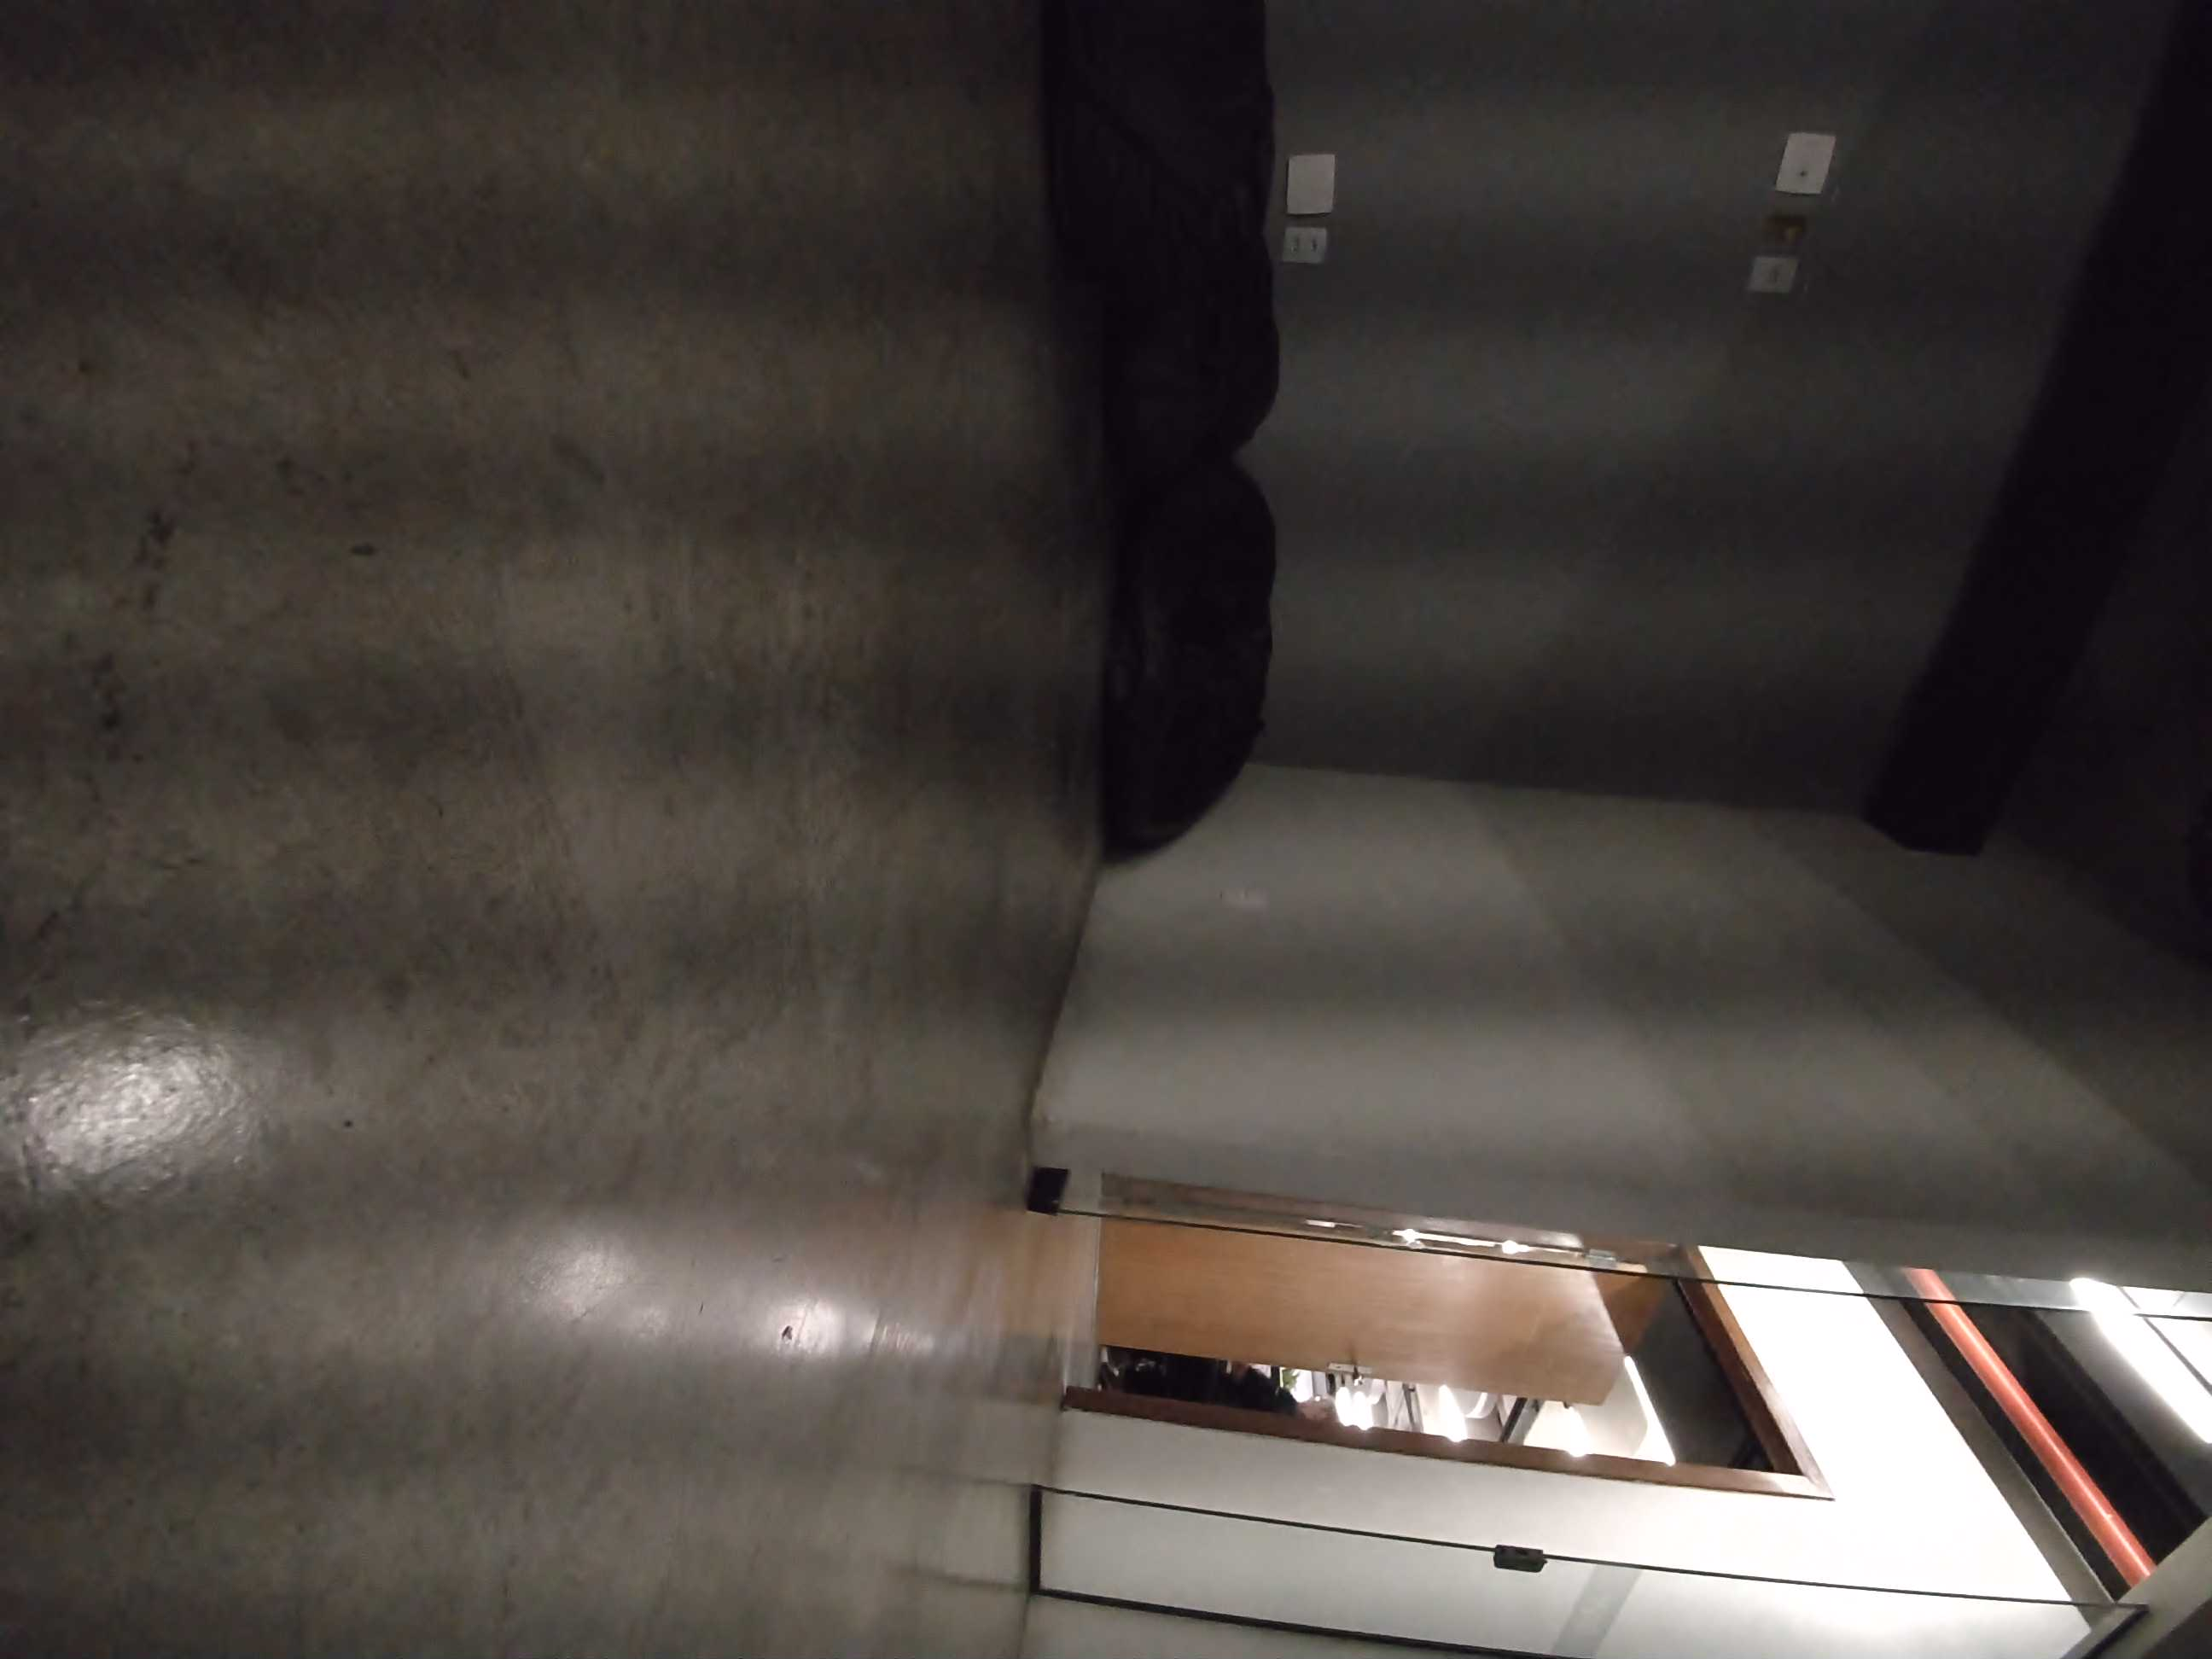

In [5]:
frames0 = os.listdir(os.path.join(dados_dir, "camera0"))
print("Quantidade de frames da câmera 3:", len(frames0))
frames1 = os.listdir(os.path.join(dados_dir, "camera1"))
print("Quantidade de frames da câmera 1:", len(frames1))
frames2 = os.listdir(os.path.join(dados_dir, "camera2"))
print("Quantidade de frames da câmera 2:", len(frames2))

# Abrindo a primeira imagem da câmera 1
from PIL import Image
print(f"Câmera 1 - 1ª img: {frames1[0]}:")
image_path = os.path.join(dados_dir, "camera1", frames1[0])
image = Image.open(image_path)
image

### 1.2. O Arquivo de calibração 

In [6]:
# Ler o arquivo de calibração
with open(os.path.join(dados_dir, calibration_file), "r") as f:
    calib_data = f.read()
    print(calib_data)

version: 20230525
parameters:
  hardware:
    slam_100-sn: SLAM100242801059
    lidar2rasterR: [0.01498514, -0.00045287, -0.00149213, 0.99988653]
    pcl2imuR: [0.00376496, 0.00057422, 0.00358588, 0.99998632]
    pcl2imuT: [0.06787, 0.00825, 0.12309]
    lidarCorrect: [-0.1, 0.0]
    code: AgAAAIKpALon5B67WklNvEjhOkCPwvU8AABgwWscFD2pCTM8AAAAAI/C9Tyq9qW8H+/5vGDfAr1cj05BEegGPCVY27yby8c8oIbqPDLbN7pN2lS8XDkHPQAAAACCLzU8NIfFPK69Cj0F1ti8CtcjPQAAAABB0zG7EaXEPNUsIbz53Y+7AAAgwQ0azDub+u68I2ASPAAAAACgKd+8AADAQPgw3rwAAAAA3zA5Op326rwp49Y8dex6vHabyDzKaNo8pAYNPQ5HvbtI4WC7xlC2PIJW2DwAAAAAcaXIvHIc/jxmaJO7Sikfux1enbwAAAAAwYnSvJuwhbzsUXDB+ijqvA7L2bwxwVc81x2qPLUN5bxfq968my9HPDwyDzxPPQI9GrXtvHxaDD24Hp1AAAAAAOzpYzzXo6DAgAe5POF63EBAKQE9QR08PAAAQMEK16M8AAAAAKheoDyd4RY91VcfPFfwyrwgZD+8essWPQ6IHD3KPh49Cv8VPblaiDsac0W8HKMYuweOi7wAAAAAAAAAAGUvMbtiji09PS4KvCfe47zGyiC8RZLrPDyr47x+l428j1GyPMY/ULxIYwo99tqAvPj0RLrJgxc8rp6NvLpm5LzjFxw9AAAAAOmAcLztrIK5jez3vEI8RzxM2D08sBi6PLChPLxVGWQ8vJ3AvLgehb9Zqq685/aHPFZogzxKFaE8BRNSv

### 1.3 Transformação LiDAR  $\rightarrow$  2º Plataforma giratória

<center><img src="media/imgs/src_pandar.png" ></center>

<center><img src="media/imgs/src_lidar.png" ></center>

> lidar2rasterR: [0.01498514, -0.00045287, -0.00149213, 0.99988653]

Não é informado em lugar nenhum mas parece uma matriz de rotação por Quaternions. Onde o quaternion unitário $q = (x, y, z, w)$ (ou $q = xi + yj + zk + w$) leva a matriz de rotação 3×3 dada por:

$
R = \begin{bmatrix}
1 - 2y^{2} - 2z^{2} & 2xy - 2wz & 2xz + 2wy \\
2xy + 2wz & 1 - 2x^{2} - 2z^{2} & 2yz - 2wx \\
2xz - 2wy & 2yz + 2wx & 1 - 2x^{2} - 2y^{2}
\end{bmatrix}
$

Para isso o Quaternion deve ser unitário: ($x^{2} + y^{2} + z^{2} + w^{2} = 1$)

A conversão em ângulos de Euler é dada por:

$$ \boxed{ \begin{aligned} 
pitch &= \phi = \operatorname{atan2} \left(-r_{31},\sqrt{r_{11}^2+r_{21}^2}\right)\\
roll &= \omega = \operatorname{atan2}(r_{32},r_{33})\\ 
yaw &= \kappa = \operatorname{atan2}(r_{21},r_{11}) \end{aligned}} $$


In [36]:
# Explorador interativo de quaternions: convencao SciPy [x, y, z, w].
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from scipy.spatial.transform import Rotation

matriz_quaternion = widgets.HTML()
eixo_quaternion = widgets.HTML()
angulo_quaternion = widgets.HTML()
euler_equiv = widgets.HTML()

def mostrar_rotacao_quaternion(x, y, z, w):
    componentes = np.array([x, y, z, w], dtype=float)
    norma = np.linalg.norm(componentes)
    if norma < 1e-12:
        matriz_quaternion.value = "<b>Quaternion nulo:</b> altere pelo menos um componente."
        return

    unitario = componentes / norma
    rotacao = Rotation.from_quat(unitario)
    matriz = rotacao.as_matrix()
    vetor_inicial = np.array([1.0, 0.0, 0.0])
    vetor_final = rotacao.apply(vetor_inicial)
    vetor_rotacao = rotacao.as_rotvec()
    yaw, pitch, roll = rotacao.as_euler('zyx', degrees=True)
    angulo = np.linalg.norm(vetor_rotacao)
    # Na identidade, o eixo e indeterminado e a trajetoria reduz-se a um ponto.
    eixo = vetor_rotacao / angulo if angulo > 1e-12 else None
    fracoes = np.linspace(0.0, 1.0, 100)
    trajetoria = Rotation.from_rotvec(
        fracoes[:, None] * vetor_rotacao
    ).apply(vetor_inicial)

    # print("Convencao: [x, y, z, w]; vetor coluna: v' = R @ v")
    # print(f"Norma de entrada: {norma:.6f} (normalizacao automatica)")
    # print("Quaternion unitario:", np.array2string(unitario, precision=6))
    matriz_quaternion.value = (
        "<b>Matriz de rotação R:</b><pre>"
        + np.array2string(matriz, precision=6, suppress_small=True)
        + "</pre>"
    )
    eixo_quaternion.value = (
        "<b>Eixo de rotação:</b> "
        + np.array2string(eixo, precision=6, suppress_small=True)
    )
    # print("R @ (1, 0, 0):", np.array2string(vetor_final, precision=6, suppress_small=True))
    # print(f"Angulo da rotação equivalente mais curta: {np.degrees(angulo):.3f} graus")
    angulo_quaternion.value = (
                "<b>Ângulo de rotação:</b> "+ f"{np.degrees(angulo):.3f}°"
            )
    euler_equiv.value = (
        "<b>Ângulos de Euler equivalentes:</b><br>"
        + f"Pitch: {pitch:.3f}°<br>"
        + f"Roll: {roll:.3f}°<br>"
        + f"Yaw: {yaw:.3f}°<br>"
    )
    # print("Eixo:", np.array2string(eixo, precision=6) if eixo is not None else "indeterminado (identidade)")


    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for direcao, nome in zip(np.eye(3), ["X", "Y", "Z"]):
        ax.plot(*np.array([-direcao, direcao]).T, color="lightgray", linewidth=1)
        ax.text(*(1.12 * direcao), nome, color="gray")
    ax.quiver(0, 0, 0, *vetor_inicial, color="tab:blue", arrow_length_ratio=0.12,
              linewidth=2, label="Vetor inicial (1, 0, 0)")
    ax.quiver(0, 0, 0, *vetor_final, color="tab:orange", arrow_length_ratio=0.12,
              linewidth=2, label="Vetor rotacionado")
    ax.plot(*trajetoria.T, color="tab:orange", linestyle="--", label="Trajetoria da rotacao")
    ax.scatter(*vetor_final, color="tab:orange", s=35)
    if eixo is not None:
        ax.plot(*np.array([-eixo, eixo]).T, color="tab:green", linestyle=":")
        ax.quiver(0, 0, 0, *eixo, color="tab:green", arrow_length_ratio=0.12,
                  label="Eixo de rotacao")
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), zlim=(-1.2, 1.2),
           xlabel="X", ylabel="Y", zlabel="Z", title="Rotacao do vetor unitario")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=-55)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


# Valores iniciais da calibracao lidar2rasterR, na ordem [x, y, z, w].
componentes_iniciais = [0.99988653, 0.01498514, -0.00045287, -0.00149213 ]
# componentes_iniciais = [0.00376496, 0.00057422, 0.00358588, 0.99998632]
sliders_quaternion = {
    nome: widgets.FloatSlider(
        value=valor, min=-1.0, max=1.0, step=0.001, description=nome,
        readout_format=".6f", continuous_update=False,
        style={"description_width": "25px"}, layout=widgets.Layout(width="420px"),
    )
    for nome, valor in zip(["x", "y", "z", "w"], componentes_iniciais)
}
saida_quaternion = widgets.interactive_output(mostrar_rotacao_quaternion, sliders_quaternion)
controles_quaternion = widgets.VBox([
    widgets.HTML(
        "<b>Quaternion [x, y, z, w]</b><br>"
        "Mova os sliders ou edite os valores. A matriz e o grafico atualizam ao soltar o slider. "
        "Os componentes sao normalizados em conjunto; q e -q representam a mesma rotação."
    ),
    *sliders_quaternion.values(),
    matriz_quaternion,
    eixo_quaternion,
    angulo_quaternion,
    euler_equiv
], layout=widgets.Layout(width="440px", flex="0 0 440px"))
saida_quaternion.layout = widgets.Layout(flex="1 0 600px", min_width="600px")
display(widgets.HBox(
    [controles_quaternion, saida_quaternion],
    layout=widgets.Layout(align_items="flex-start", width="100%", overflow="auto"),
))

![alt text](media/imgs/quaternions.png)

In [8]:
import numpy as np

q = np.array(componentes_iniciais)
np.linalg.norm(q)  # Deve ser 1.0

np.float64(1.0000000294197169)

In [9]:
from scipy.spatial.transform import Rotation

# Hipotese explicita; xyzw preserva a convencao executada neste notebook.
# Para testar wxyz, altere esta variavel e reexecute as secoes 3.1, 7 e 8.
ORDEM_QUATERNION_LIDAR_RASTER = "xyzw"

if ORDEM_QUATERNION_LIDAR_RASTER not in ("xyzw", "wxyz"):
    raise ValueError("Use xyzw ou wxyz")
q_scipy = q if ORDEM_QUATERNION_LIDAR_RASTER == "xyzw" else q[[1, 2, 3, 0]]
R_lidar_para_raster = Rotation.from_quat(q_scipy).as_matrix()
print("Ordem interpretada:", ORDEM_QUATERNION_LIDAR_RASTER)
print("R_lidar_para_raster:\n", R_lidar_para_raster)


Ordem interpretada: xyzw
R_lidar_para_raster:
 [[ 9.99550481e-01  2.99655260e-02 -9.50356724e-04]
 [ 2.99682290e-02 -9.99546438e-01  2.97034856e-03]
 [-8.60917621e-04 -2.99749384e-03 -9.99995137e-01]]


Seguida por uma rotação no sentido anti-horário em torno no novo eixo y ($\phi$):

$R_{y}(\phi) = \begin{bmatrix} cos(\phi) &0 & -sen(\phi)\\0&1&0\\sen(\phi)&0&cos(\phi) \end{bmatrix}$, onde $\phi$ é função do tempo e do RPM da 2ª plataforma giratória.

Assim:

$\mathbf{p_{pcl}} = R_y(\phi) \ _{raster}R_{lidar} \ \mathbf{p_{lidar}}$

### 1.4 Transformação 2º Plataforma giratória $\rightarrow$ IMU

In [10]:
# Transformação rígida da point cloud/plataforma RASTER para a IMU:
# p_imu = R_raster_para_imu @ p_raster + t_raster_para_imu
pcl2imuR = [0.00376496, 0.00057422, 0.00358588, 0.99998632]
pcl2imuT = [0.06787, 0.00825, 0.12309]
q_raster_para_imu = np.asarray(pcl2imuR, dtype=float)
t_raster_para_imu = np.asarray(pcl2imuT, dtype=float)

R_raster_para_imu = Rotation.from_quat(q_raster_para_imu).as_matrix()
T_raster_para_imu = np.eye(4)
T_raster_para_imu[:3, :3] = R_raster_para_imu
T_raster_para_imu[:3, 3] = t_raster_para_imu

print("Transformação homogênea RASTER -> IMU:")
print(T_raster_para_imu)

Transformação homogênea RASTER -> IMU:
[[ 0.99997362 -0.00716734  0.00117543  0.06787   ]
 [ 0.00717599  0.99994593 -0.0075257   0.00825   ]
 [-0.00112142  0.00753394  0.99997099  0.12309   ]
 [ 0.          0.          0.          1.        ]]


Assim:

$\mathbf{p_{imu}} = _{imu}T_{raster} \ \mathbf{p_{pcl}}$

### 1.5 code: uma string de dados base64

In [11]:
# Ler o arquivo de calibração
with open(os.path.join(dados_dir, calibration_file), "r") as f:
    lines = f.readlines()
    for line in lines:
        if "code" in line:
            print(line)
            code = line.split(" ")[-1]

    code: AgAAAIKpALon5B67WklNvEjhOkCPwvU8AABgwWscFD2pCTM8AAAAAI/C9Tyq9qW8H+/5vGDfAr1cj05BEegGPCVY27yby8c8oIbqPDLbN7pN2lS8XDkHPQAAAACCLzU8NIfFPK69Cj0F1ti8CtcjPQAAAABB0zG7EaXEPNUsIbz53Y+7AAAgwQ0azDub+u68I2ASPAAAAACgKd+8AADAQPgw3rwAAAAA3zA5Op326rwp49Y8dex6vHabyDzKaNo8pAYNPQ5HvbtI4WC7xlC2PIJW2DwAAAAAcaXIvHIc/jxmaJO7Sikfux1enbwAAAAAwYnSvJuwhbzsUXDB+ijqvA7L2bwxwVc81x2qPLUN5bxfq968my9HPDwyDzxPPQI9GrXtvHxaDD24Hp1AAAAAAOzpYzzXo6DAgAe5POF63EBAKQE9QR08PAAAQMEK16M8AAAAAKheoDyd4RY91VcfPFfwyrwgZD+8essWPQ6IHD3KPh49Cv8VPblaiDsac0W8HKMYuweOi7wAAAAAAAAAAGUvMbtiji09PS4KvCfe47zGyiC8RZLrPDyr47x+l428j1GyPMY/ULxIYwo99tqAvPj0RLrJgxc8rp6NvLpm5LzjFxw9AAAAAOmAcLztrIK5jez3vEI8RzxM2D08sBi6PLChPLxVGWQ8vJ3AvLgehb9Zqq685/aHPFZogzxKFaE8BRNSvEs5Bb1BZow8GkMEvOxgSbxk47g7m9inu979krzh6HO8j8L1PORSjzw+o4Q8rCxSvB+67rwLDoA8FFazO/Vn/LwLyt88do0Nu0de+rxYKbC8cT0OQdFa9LxfksQ8AAAAAPaKqzyZueS8cT0uQQrXozyoPLa8CtejPBhX4LwAAAAAAVUJPQAA4MCBvjE7oMOkPB6GHbw4lCM921uwPJi3QLyOeTK7OXS5vBExiby9Qgo9LNL9vMB5xrw9fF67AABQwQAAAABmuqW6BrnwOTMzb0EAAA

In [12]:
"""
Decodifica o campo `code:` do arquivo feima_slam100_calib.yaml (Feima SLAM 100).

Layout descoberto:
    bytes 0..3     : int32 little-endian (valor = 2, provavel versao/num. de tabelas)
    bytes 4..1827  : 456 x float32 little-endian

Dentro desses 456 floats estao dispersos 32 valores "grandes" (|x| > 0.5) que
correspondem aos angulos de elevacao (vertical) dos canais do LiDAR, em graus.
O restante sao valores pequenos (|x| < 0.05), compativeis com offsets/ruido.
"""

import base64
import struct
import sys

import numpy as np


def decode(code_b64: str):
    raw = base64.b64decode(code_b64.strip())
    header = struct.unpack_from("<i", raw, 0)[0]
    vals = np.frombuffer(raw[4:], dtype="<f4")
    return header, vals


def elevations(vals: np.ndarray, thr: float = 0.5):
    """Retorna [(indice, angulo_graus)] dos angulos de elevacao."""
    idx = np.where(np.abs(vals) > thr)[0]
    return sorted(((float(vals[i]), int(i)) for i in idx))


header, vals = decode(code)

print(f"header (int32) : {header}")
print(f"n floats       : {len(vals)}")
print(f"zeros exatos   : {int((vals == 0).sum())}")
print()

print("Angulos de elevacao recuperados (graus):")
for ang, i in elevations(vals):
    print(f"  idx {i:3d}  {ang:8.2f}")
print()

print("Dump completo (indice: valor):")
for i in range(0, len(vals), 8):
    row = " ".join(f"{v:12.6g}" for v in vals[i:i + 8])
    print(f"{i:4d}  {row}")

header (int32) : 2
n floats       : 456
zeros exatos   : 33

Angulos de elevacao recuperados (graus):
  idx 265    -16.00
  idx  61    -15.02
  idx   5    -14.00
  idx 179    -13.00
  idx  81    -12.00
  idx 283    -10.99
  idx  32    -10.00
  idx 296     -9.01
  idx 430     -8.00
  idx 165     -7.00
  idx 447     -6.00
  idx  76     -5.02
  idx 304     -4.00
  idx 208     -3.04
  idx 438     -2.00
  idx 126     -1.04
  idx 417      0.94
  idx 271      2.00
  idx   3      2.92
  idx 278      4.00
  idx  73      4.91
  idx  38      6.00
  idx  78      6.89
  idx 309      8.00
  idx 152      8.89
  idx 401     10.00
  idx 158     10.89
  idx 205     12.00
  idx  13     12.91
  idx 331     14.00
  idx 183     14.95

Dump completo (indice: valor):
   0  -0.000490807  -0.00242449   -0.0125297         2.92         0.03          -14    0.0361599    0.0109276
   8             0         0.03   -0.0202592   -0.0305095   -0.0319513        12.91   0.00823404   -0.0267754
  16     0.0243891    0.02

## 2. O Arquivo "RASTER"

In [13]:
# Ler o arquivo de segunda plataforma giratória (RASTER)
print(second_platform_file)
l =100
with open(os.path.join(dados_dir, second_platform_file), "r") as f:
    for line in f.readlines():
        print(line, end="")
        l -= 1
        if l == 0:
            break

241023-122500_00007_RASTER_DATA_0001.txt
SAMPTIME    	DIR         INC         ANGLE       NUM         
304015.655487,0,224,39.375000,52
304015.656362,0,225,39.550781,52
304015.657238,0,226,39.726562,52
304015.658127,0,227,39.902344,52
304015.659017,0,228,40.078125,52
304015.659905,0,229,40.253906,52
304015.660816,0,230,40.429688,52
304015.661758,0,231,40.605469,52
304015.662689,0,232,40.781250,52
304015.663607,0,233,40.957031,52
304015.664530,0,234,41.132812,52
304015.665456,0,235,41.308594,52
304015.666375,0,236,41.484375,52
304015.667300,0,237,41.660156,52
304015.668240,0,238,41.835938,52
304015.669213,0,239,42.011719,52
304015.670173,0,240,42.187500,52
304015.671118,0,241,42.363281,52
304015.672067,0,242,42.539062,52
304015.673032,0,243,42.714844,52
304015.673981,0,244,42.890625,52
304015.674931,0,245,43.066406,52
304015.675898,0,246,43.242188,52
304015.676881,0,247,43.417969,52
304015.677857,0,248,43.593750,52
304015.678819,0,249,43.769531,52
304015.679786,0,250,43.945312,52
304015

### 2.1 Análise da periodicidade

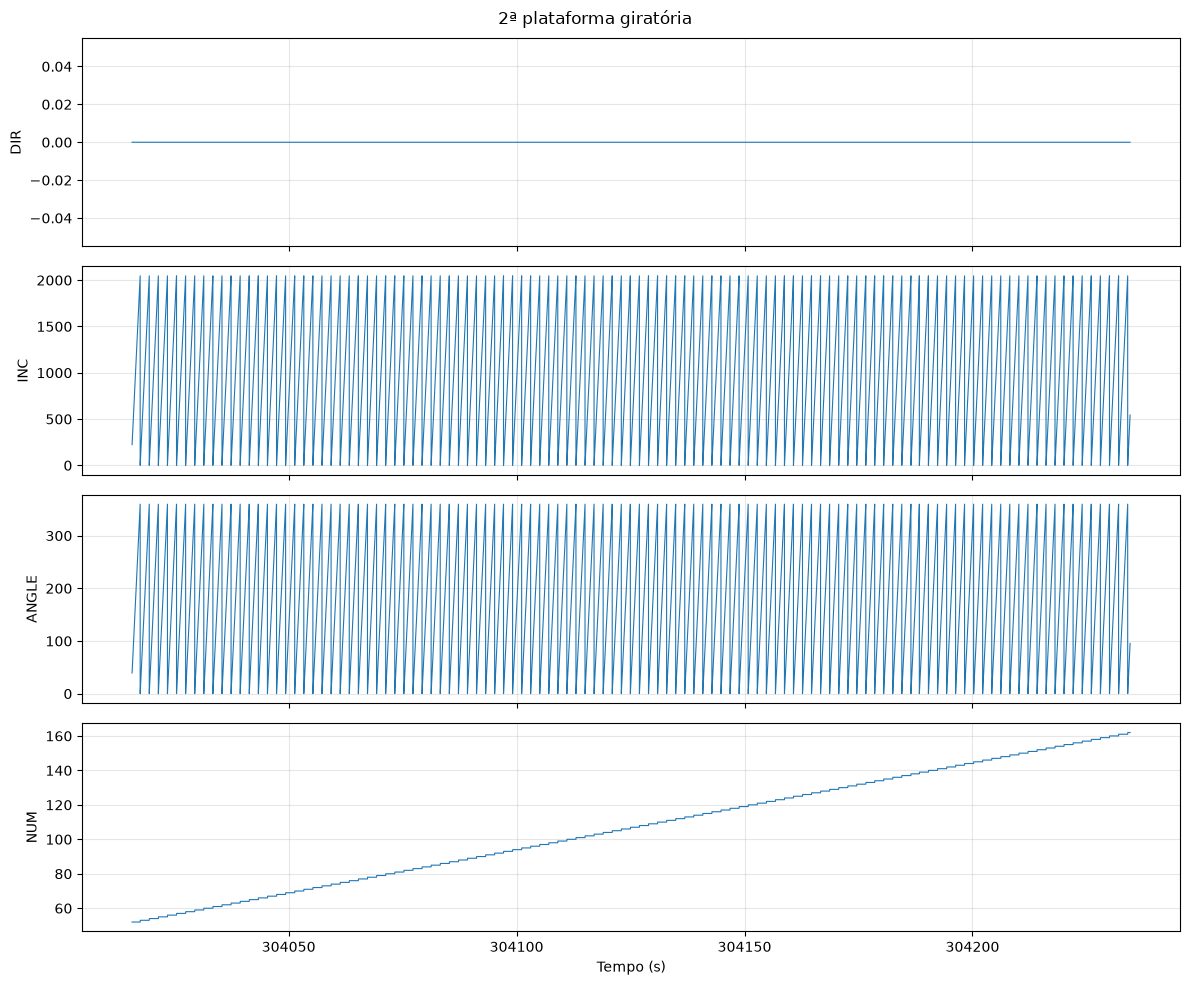

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raster_columns = ["SAMPTIME", "DIR", "INC", "ANGLE", "NUM"]
raster_data = pd.read_csv(
    os.path.join(dados_dir, second_platform_file),
    skiprows=1, names=raster_columns
)
raster_data = raster_data.apply(pd.to_numeric, errors="coerce").dropna()
raster_variables = raster_columns[1:]

fig, axes = plt.subplots(len(raster_variables), 1, figsize=(12, 10), sharex=True)
for ax, variable in zip(axes, raster_variables):
    ax.plot(raster_data["SAMPTIME"], raster_data[variable], linewidth=0.8)
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("2ª plataforma giratória")
fig.tight_layout()
plt.show()

Dados de ângulos cíclicos condizendo com o esperado. Qual a frequência?

,SAMPTIME,DIR,INC,ANGLE,NUM
0,304015.655487,0,224,39.375,52
2048,304017.648388,0,224,39.375,53
4096,304019.642620,0,224,39.375,54
6144,304021.637134,0,224,39.375,55
8192,304023.631791,0,224,39.375,56


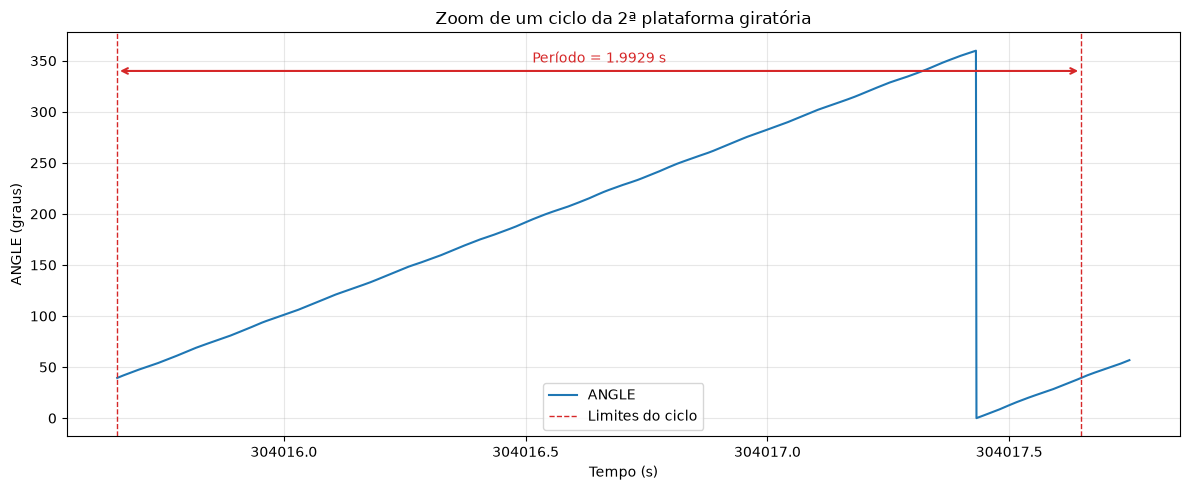

Período do ciclo: 1.992901 s
Frequência: 30.106864 RPM


In [15]:
from IPython.display import display
from matplotlib.ticker import FuncFormatter

# Cada queda de aproximadamente 360° para 0° marca o início de um novo ciclo.
angle_values = raster_data["ANGLE"].to_numpy()

cycle_start = angle_values[0]
angle_cycle_loop = raster_data.loc[raster_data["ANGLE"]==cycle_start].copy()
display(angle_cycle_loop.head())
cycle_start_time = angle_cycle_loop["SAMPTIME"].iloc[0]
cycle_end_time = angle_cycle_loop["SAMPTIME"].iloc[1]
cycle_period_s = cycle_end_time - cycle_start_time
cycle_frequency_hz = 1.0 / cycle_period_s
cycle_frequency_RPM = cycle_frequency_hz *60

df_one_loop = raster_data.iloc[angle_cycle_loop.index[0]:angle_cycle_loop.index[1]+100]
fig, ax = plt.subplots(figsize=(12, 5))
df_one_loop.plot(x="SAMPTIME", y="ANGLE", color="tab:blue", linewidth=1.5, ax=ax)

ax.axvline(cycle_start_time, color="tab:red", linestyle="--", linewidth=1, label="Limites do ciclo")
ax.axvline(cycle_end_time, color="tab:red", linestyle="--", linewidth=1)
ax.annotate(
    "", xy=(cycle_start_time, 340), xytext=(cycle_end_time, 340),
    arrowprops={"arrowstyle": "<->", "color": "tab:red", "linewidth": 1.5},
)
ax.text(
    cycle_start_time+ cycle_period_s / 2, 345,
    f"Período = {cycle_period_s:.4f} s",
    ha="center", va="bottom", color="tab:red",
)

ax.set(
    title="Zoom de um ciclo da 2ª plataforma giratória",
    xlabel="Tempo (s)",
    ylabel="ANGLE (graus)",
)

def formatter(x, pos):
    return f'{x}'

ax.xaxis.set_major_formatter(FuncFormatter(formatter))

ax.grid(alpha=0.3)
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

print(f"Período do ciclo: {cycle_period_s:.6f} s")
print(f"Frequência: {cycle_frequency_RPM:.6f} RPM")

### 2.2 Interpolação para obtenção do ângulo para qualquer tempo

Para interpolar entre duas amostras que envolvem o instante desejado:

$\theta(t)=\theta_0+\frac{t-t_0}{t_1-t_0}(\theta_1-\theta_0)$.

Antes da interpolacao, remover as descontinuidades de 360 graus (`unwrap`). Fora da cobertura temporal, retornar `NaN`, sem extrapolar.


In [16]:
def get_closest_row(df, target, column="SAMPTIME"):
    closest_rows = df.iloc[(df[column] - target).abs().argsort()[:2]]
    return closest_rows

get_closest_row(raster_data, target=304015.751574)

,SAMPTIME,DIR,INC,ANGLE,NUM
95,304015.751446,0,319,56.074219,52
96,304015.752430,0,320,56.250000,52


In [17]:
def interpolar_angulos_raster(df, tempos, angle_column="ANGLE"):
    serie = (df[["SAMPTIME", angle_column]].apply(pd.to_numeric, errors="coerce")
             .dropna().sort_values("SAMPTIME").drop_duplicates("SAMPTIME", keep="last"))
    if len(serie) < 2:
        raise ValueError("Sao necessarias pelo menos duas amostras RASTER.")
    angulos = np.unwrap(np.deg2rad(serie[angle_column].to_numpy()))
    interpolados = np.interp(tempos, serie["SAMPTIME"].to_numpy(), angulos,
                            left=np.nan, right=np.nan)
    return np.rad2deg(interpolados) % 360.0


def get_precise_angle_given_time(df, desired_time, angle_column="ANGLE"):
    return float(interpolar_angulos_raster(df, desired_time, angle_column))

t = 304015.751574
display(get_closest_row(raster_data, target=t))
print(f"SAMPTIME={t}\t ANGLE={get_precise_angle_given_time(raster_data, desired_time=t)}")

,SAMPTIME,DIR,INC,ANGLE,NUM
95,304015.751446,0,319,56.074219,52
96,304015.752430,0,320,56.250000,52


SAMPTIME=304015.751574	 ANGLE=56.097084818855684


### 2.3 Interpretação da coluna tempo

In [18]:
raster_data["SAMPTIME"].values

array([304015.655487, 304015.656362, 304015.657238, ..., 304234.575858,
       304234.576839, 304234.577827], shape=(225600,))

O Timestamp UTC do projeto está gravado no nome do arquivo `241023-122500_00007_RASTER_DATA_0001.txt`:

In [19]:
from datetime import datetime, timedelta, timezone

print(second_platform_file) 
datahora = second_platform_file.split("_")[0]
aammdd, hhmmss = datahora.split("-")
print(aammdd, hhmmss) 
t = datetime.fromisoformat(f"20{aammdd[0:2]}-{aammdd[2:4]}-{aammdd[4:]} {hhmmss[0:2]}:{hhmmss[2:4]}:{hhmmss[4:]}.0+00:00")
print(t) 

241023-122500_00007_RASTER_DATA_0001.txt
241023 122500
2024-10-23 12:25:00+00:00


Não é informado em lugar nenhum mas parece que a coluna `SAMPTIME` são Time of Week GPS (TOW), ou seja, a quantidade de segundos desde domingo 00:00:00 UTC. Por exemplo para o timestamp:

2024-10-23 12:26:56.277259+00:00 o início da semana correspondente é domingo, 2024-10-20 00:00:00 UTC e portanto:

$$ \boxed{TOW=304016.277259\ \text{s}} $$


In [20]:
t = datetime.fromisoformat("2024-10-23 12:26:56.277259+00:00")

# Python: Monday=0 ... Sunday=6
days_since_sunday = (t.weekday() + 1) % 7

sunday = (t - timedelta(days=days_since_sunday)).replace(
    hour=0, minute=0, second=0, microsecond=0
)

tow = (t - sunday).total_seconds()

print("Sunday:", sunday)
print("TOW:", tow)

Sunday: 2024-10-20 00:00:00+00:00
TOW: 304016.277259


Ou seja, 304016.277259 segundos desde domingo às 00:00:00 UTC, o que condiz com a ordem de grandeza dos dados.

## 5. Arquivo "IMU"

In [21]:
# Ler o arquivo do sensor inercial (IMU)
print(imu_file)
l =10
with open(os.path.join(dados_dir, imu_file), "r") as f:
    for line in f.readlines():
        print(line, end="")
        l -= 1
        if l == 0:
            break

241023-122500_00007_IMU_DATA_0001.txt
SAMPTIME    	ACCX        ACCY        ACCZ        GYRX        GYRY        GYRZ        Q0          Q1          Q2          Q3          
304015.593015,-1.187655,0.021507,9.878807,-0.003725,0.021817,-0.003725,0.998307,-0.000000,0.000000,-0.000000
304015.594015,-1.354931,0.140989,9.066326,-0.004789,0.006917,-0.006385,0.998312,0.000115,0.001103,-0.000000
304015.595015,-1.135083,0.172055,9.506021,0.000532,-0.005321,-0.006917,0.998310,0.000247,0.001970,-0.000000
304015.596015,-1.027549,0.186393,10.072369,0.005321,0.004789,-0.003193,0.998309,0.000380,0.002697,-0.000000
304015.597015,-1.276072,0.109924,9.728259,0.007450,0.013835,0.006917,0.998306,0.000458,0.003626,-0.000000
304015.598015,-1.412282,-0.038234,9.711532,0.008514,-0.000532,0.014899,0.998301,0.000423,0.004645,-0.000001
304015.599015,-1.142252,-0.093196,10.304164,0.009578,-0.004257,0.015963,0.998298,0.000349,0.005396,-0.000001
304015.600015,-0.977366,-0.054962,10.151227,0.007982,0.009578,0.015963,0

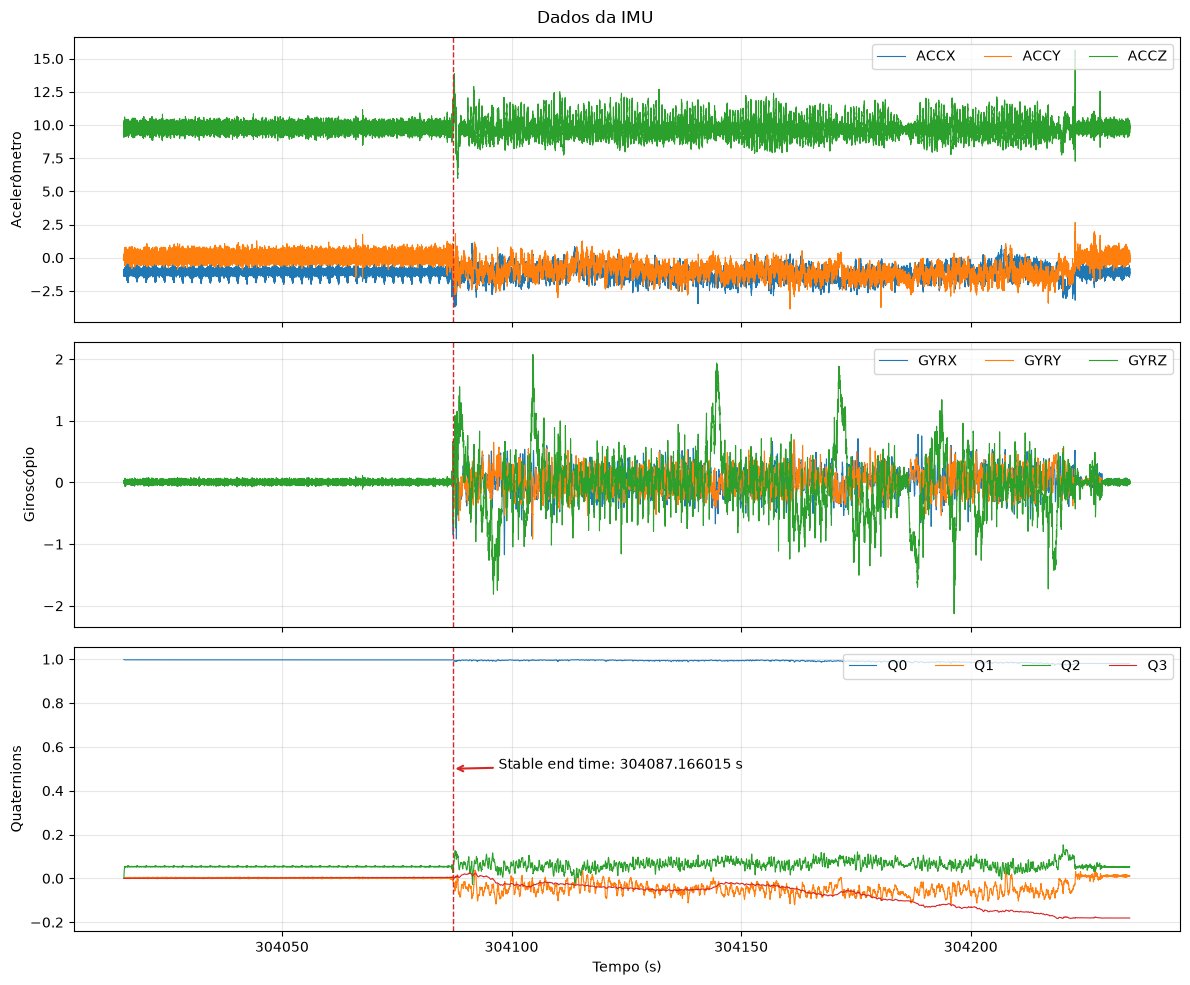

In [22]:
imu_columns = [
    "SAMPTIME", "ACCX", "ACCY", "ACCZ",
    "GYRX", "GYRY", "GYRZ", "Q0", "Q1", "Q2", "Q3"
]
imu_data = pd.read_csv(
    os.path.join(dados_dir, imu_file),
    skiprows=1, names=imu_columns
)
imu_data = imu_data.apply(pd.to_numeric, errors="coerce").dropna()
imu_groups = {
    "Acelerômetro": ["ACCX", "ACCY", "ACCZ"],
    "Giroscópio": ["GYRX", "GYRY", "GYRZ"],
    "Quaternions": ["Q0", "Q1", "Q2", "Q3"],
}

# Identificar o maior período contínuo em que a IMU permaneceu estável.
gyro_variables = ["GYRX", "GYRY", "GYRZ"]
gyro_norm = np.sqrt(imu_data[gyro_variables].pow(2).sum(axis=1))
sample_interval_s = imu_data["SAMPTIME"].diff().median()
stability_window = max(1, round(1.0 / sample_interval_s))
smoothed_gyro_norm = gyro_norm.rolling(
    window=stability_window, center=True, min_periods=1
).median()

# Valores abaixo deste limiar indicam ausência de rotação relevante.
gyro_stability_threshold = 0.10
stable_mask = smoothed_gyro_norm < gyro_stability_threshold
stable_block = stable_mask.ne(stable_mask.shift()).cumsum()
stable_segments = (
    imu_data.loc[stable_mask]
    .groupby(stable_block.loc[stable_mask])["SAMPTIME"]
    .agg(start="first", end="last")
)
stable_segments["duration"] = stable_segments["end"] - stable_segments["start"]
stable_start_time, stable_end_time = stable_segments.loc[
    stable_segments["duration"].idxmax(), ["start", "end"]
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, (group_name, variables) in zip(axes, imu_groups.items()):
    for variable in variables:
        ax.plot(imu_data["SAMPTIME"], imu_data[variable], label=variable, linewidth=0.8)
    ax.set_ylabel(group_name)
    ax.axvline(stable_end_time, color="tab:red", linestyle="--", linewidth=1)

    ax.legend(ncol=len(variables), loc="upper right")
    ax.grid(alpha=0.3)

ax.annotate(
    f"Stable end time: {stable_end_time} s", xy=(stable_end_time, 0.5), xytext=(stable_end_time+10, 0.5),
    arrowprops={"arrowstyle": "->", "color": "tab:red", "linewidth": 1.5},
)

axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("Dados da IMU")
fig.tight_layout()
plt.show()


In [23]:
print(f"Stable end time: {stable_end_time} s \nStable start time: {stable_start_time} s\nDuration: {stable_end_time - stable_start_time} s")

Stable end time: 304087.166015 s 
Stable start time: 304015.593015 s
Duration: 71.57300000003306 s


## 6. A captura UDP dos dados LiDAR `.pcap`

https://www.hesaitech.com/downloads/#xt32-16

Requisitos:
- WireShark
- [Pandar View 2](https://hesaitechnology.github.io/dev/docs/how_to_guides/PandarView/)
- [Python pypcapkit](https://jarryshaw.github.io/PyPCAPKit/)

### 6.1 Wireshark

![alt text](media/imgs/ws.png)

### 6.2 Pandar view

![alt text](media/imgs/pandar.png)

### 6.3 Python pcapkit

In [24]:
from pcapkit import extract
import os
# Extract packets from a PCAP file
with extract(fin=os.path.join(dados_dir, pcap_file), auto=False, store=False, nofile=True, engine="default") as capture:
    for frame in capture:
        if "UDP" not in frame:
            continue

        udp = frame["UDP"]
        first_payload = udp.packet.payload
        break

In [25]:
from pprint import pprint
print("First UDP payload:",len(first_payload), "bytes")
pprint(first_payload)

First UDP payload: 568 bytes
(b'\xee\xff\x06\x01\x00\x00\x10\x08\x00\x04\x02\x01\xcd_\t\x03\x1c\xff\x08\x03'
 b'\x1f\xff\x06\x03\x1c\xff\x07\x03\x1c\xff\x05\x03\x19\xff\x08\x03'
 b'\x1c\xff\x0b\x03\x1d\xff\x0e\x03\x1c\xff\x13\x03\x1e\xff\x17\x03'
 b'\x1a\xff\x1e\x03\x1b\xff$\x03\x19\xff+\x03\x17\xff6\x03\x17\xffB\x03'
 b'\x18\xffL\x03\x18\xff\xdf_\x08\x03\x1d\xff\x07\x03\x1f\xff\x05\x03\x1b\xff'
 b'\x04\x03\x1c\xff\x05\x03\x1a\xff\x08\x03\x1c\xff\t\x03\x1c\xff\r\x03\x1c\xff'
 b'\x11\x03\x1d\xff\x17\x03\x19\xff\x1d\x03\x1a\xff"\x03\x19\xff+\x03\x19\xff'
 b'5\x03\x17\xff@\x03\x19\xffM\x03\x18\xff\xf1_\x07\x03\x1d\xff\x06\x03'
 b'\x1e\xff\x03\x03\x1d\xff\x04\x03\x1b\xff\x02\x03\x1b\xff\x07\x03'
 b'\x1c\xff\x08\x03\x1d\xff\x0c\x03\x1c\xff\x12\x03\x1e\xff\x15\x03'
 b'\x1b\xff\x1d\x03\x1a\xff!\x03\x19\xff(\x03\x18\xff4\x03\x17\xff=\x03'
 b'\x19\xffL\x03\x18\xff\x03`\x06\x03\x1d\xff\x04\x03\x1e\xff\x03\x03\x1c\xff'
 b'\x02\x03\x1b\xff\x01\x03\x19\xff\x05\x03\x1b\xff\x07\x03\x1c\xff'
 b'\x0c\x

**Mas o que significam esses bytes? Sabe-se que as informações LiDAR estão aí dentro!**

### 6.4 LiDAR <a href="media/manuais/PandarXT-16_User_Manual_X02-en-250810.pdf">Pandar XT16</a>: 16-Channel Mid-Range Mechanical Lidar

**Specs:**
- Number of channels 16
- Instrumented range 0.05 to 120 m
- Horizontal FOV 360°
- Vertical FOV 30° (-15° to +15°)
- Vertical resolution 2°

**Ângulo vertical:**

https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=17

<center><img src="media/imgs/pandar_xt16_channel_vertical_distribution.png" width=600></center>


In [26]:
import numpy as np
PANDAR_XT16_ELEVATION_DEG = np.arange(15.0, -16.0, -2.0)
PANDAR_XT16_ELEVATION_DEG

array([ 15.,  13.,  11.,   9.,   7.,   5.,   3.,   1.,  -1.,  -3.,  -5.,
        -7.,  -9., -11., -13., -15.])

<center><img src="media/imgs/angle_correction_file.png"></center>

In [35]:
PANDAR_XT16_ELEVATION_DEG_CORR = np.array([v[0] for v in elevations(vals) if v[0] % 2])[::-1]
PANDAR_XT16_ELEVATION_DEG_CORR

array([ 14.94999981,  12.90999985,  10.89000034,   8.89000034,
         6.88999987,   4.90999985,   2.92000008,   0.94      ,
        -1.03999996,  -3.03999996,  -5.01999998,  -7.        ,
        -9.01000023, -10.98999977, -13.        , -15.02000046])

**Data structure:** 

https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=49

<center><img src="media/imgs/pandar_xt16_data_structure.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_pre-header.jpeg"></center>

**Distância e ângulo horizontal (azimute):**

<center><img src="media/imgs/pandar_xt16_axis.png" ></center>

<center><img src="media/imgs/pandar_xt16_body.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_each_point_calc.jpeg" width=600></center>

Data point $p = [x \ y \ z]^T$

$$x =  distance_{horizontal} \times \sin{\alpha} \\
y = distance_{horizontal} \times \cos{\alpha} \\
z = distance \times \sin{\beta}$$

Onde $\alpha$ é o ângulo horizontal, $\beta$ é o ângulo vertical e $distance_{horizontal} = distance \times \cos(\beta)$.

<center><img src="media/imgs/pandar_xt16_tail.png" ></center>

O azimute informado já corresponde ao início de cada bloco. Conforme a seção 3.1.4 e o apendice B do manual, a correção angular usa somente o atraso do canal:

$\Delta t_n = 5.632 + 3.024(n-1) + 0.368$ (microssegundos).

$\alpha = (\mathrm{azimute} + \mathrm{offset\ horizontal} + (6\,RPM)\,\Delta t_n\,10^{-6}) \bmod 360$.

Para calcular o instante absoluto de diparo do ponto, usa-se separadamente $t_{m,n} = t_m + \Delta t_n\,10^{-6}$, com tempos absolutos em segundos Unix onde $t_m = t_0 - 50(8-m)\,10^{-6}$, representa o instante absoluto de disparo do bloco.

Não se usa $t_0$ nem $t_m$ na correção angular: o azimute de cada bloco já incorpora sua posição de rotação.


### 6.5 Os 1000 primeiros pacotes

In [28]:
# Ler o PCAP com pypcapkit e decodificar os pacotes UDP do Hesai PandarXT-16
import struct

import numpy as np
import pandas as pd
from pcapkit import extract

# Angulos verticais nominais dos canais 1 a 16 (manual do PandarXT-16).
# Para maior exatidao, substitua-os pelos valores do arquivo de correcao
# angular que acompanha especificamente este sensor.
PANDAR_XT16_RETURN_NAMES = {
    0x33: ("first",),
    0x37: ("strongest",),
    0x38: ("last",),
    0x39: ("last", "strongest"),
    0x3B: ("last", "first"),
    0x3C: ("first", "strongest"),
}

def segundos_desde_domingo_utc(dt: pd.Timestamp):
    if pd.isna(dt):
        return np.nan
    dt = pd.Timestamp(dt).tz_convert("UTC")
    dias_desde_domingo = (dt.weekday() + 1) % 7
    inicio_domingo = dt.normalize() - pd.Timedelta(dias_desde_domingo, unit="D")
    # Converter apenas a duracao relativa para float; total_seconds() trunca ns.
    return (dt - inicio_domingo).value / 1_000_000_000

def _pandar_xt16_packet_time(payload):
    """Converte os campos UTC do tail do pacote para pandas.Timestamp em UTC."""
    tail_offset = 12 + 8 * 66
    year, month, day, hour, minute, second = payload[tail_offset + 13:tail_offset + 19]
    # https://docs.python.org/3/library/struct.html#struct.calcsize
    # <I = little-endian unsigned int (4 bytes)
    microsecond = struct.unpack_from("<I", payload, tail_offset + 19)[0] # t_ms
    try:
        whole_second = pd.Timestamp(year=1900 + year, month=month, day=day,
                                    hour=hour, minute=minute, second=second, tz="UTC")
        packet_time = whole_second + pd.Timedelta(microsecond * 1_000, unit="ns")
        return packet_time
    except ValueError:
        # O relogio pode ainda nao estar sincronizado no inicio da captura.
        return pd.NaT


def read_pandar_xt16_pcap(path, ini_packet=0, end_packet=None):
    """Extrai pontos PandarXT-16 de um PCAP para um DataFrame.

    ini_packet e end_packet limitam os pacotes LiDAR validos. Use None para ler
    a captura inteira; capturas longas podem consumir muita memoria.
    """
    rows = []
    lidar_packet_count = 0
    ignored_udp_count = 0

    # auto=False e store=False fazem a leitura quadro a quadro, sem guardar
    # uma segunda copia de todo o PCAP na memoria.
    with extract(
        fin=path, auto=False, store=False, nofile=True, engine="default"
    ) as capture:
        for frame in capture:
            if ini_packet is not None and lidar_packet_count < ini_packet:
                lidar_packet_count += 1
                continue

            if "UDP" not in frame:
                continue

            udp = frame["UDP"]
            payload = udp.packet.payload

            # Pre-header 0xEEFF e estrutura fixa do PandarXT-16 v6.1:
            # 6 B pre-header + 6 B header + 8 * 66 B body + 24 B tail + 4 B seq.
            if (
                len(payload) != 568
                or payload[:2] != b"\xee\xff"
                or payload[6] != 16 # Header Channel Num 1 byte Fixed 0x10 (16)
                or payload[7] != 8 # Header Block Num 1 byte Fixed 0x08 (8)
                # or payload[9] != 4 # Header Dis Unit 1 byte Fixed 0x04 (4 mm)
            ):
                ignored_udp_count += 1
                continue
            
            distance_unit_m = payload[9] / 1000.0
            tail_offset = 12 + 8 * 66
            return_mode = payload[tail_offset + 10]
            motor_speed_rpm = struct.unpack_from("<H", payload, tail_offset + 11)[0]
            packet_time = _pandar_xt16_packet_time(payload)
            sequence = struct.unpack_from("<I", payload, tail_offset + 24)[0]
            return_names = PANDAR_XT16_RETURN_NAMES.get(return_mode, (f"0x{return_mode:02X}",))

            for block_index in range(8):
                block_offset = 12 + block_index * 66
                # Os primeiros 2 bytes é o azimute ou ainda
                # ③ Current reference azimuth of this block
                # Como a unidade do azimute é 0,01°, multiplica-se por 0.01
                # <H = little-endian unsigned short int (2 bytes)
                reference_azimuth_deg = struct.unpack_from("<H", payload, block_offset)[0] * 0.01
                return_name = return_names[block_index % len(return_names)]

                for channel_index, elevation_deg in enumerate(PANDAR_XT16_ELEVATION_DEG):
                    channel_offset = block_offset + 2 + channel_index * 4
                    # <H = little-endian unsigned short int (2 bytes)
                    # <B = little-endian unsigned char (1 byte)
                    distance_raw, reflectivity = struct.unpack_from("<HB", payload, channel_offset)
                    if distance_raw == 0: # lixo do sensor, ponto invalido
                        continue

                    # Como a unidade da distância é 0.04 mm,
                    # multiplica-se por 0.00004 pra dar em metros
                    distance_m = distance_raw * distance_unit_m

                    # Analyze the horizontal angle of a data point
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=59
                    
                    # ⑤ Firing time offset of the current firing channel
                    # B.3: instante do bloco, com deslocamento inteiro em ns.
                    absolute_block_firing_time = packet_time - pd.Timedelta(
                        50_000 * (7 - block_index), unit="ns"
                    )
                    # B.4: 5.632 + 3.024 * channel_index + 0.368 us.
                    firing_time_offset_ns = 6_000 + 3_024 * channel_index
                    firing_time_offset_us = firing_time_offset_ns / 1_000
                    firing_time_offset_s = firing_time_offset_ns / 1_000_000_000
                    absolute_channel_firing_time = absolute_block_firing_time + pd.Timedelta(
                        firing_time_offset_ns, unit="ns"
                    )

                    # ⑥ Spin rate of the motor
                    # See the Motor Speed field in Section 3.1.2.4 Tail. The unit should be converted to °/s
                    # rpm to deg/s: 1 rpm = 6 deg/s
                    motor_speed_deg_per_s = motor_speed_rpm * 6.0
                    
                    # ② Firing time angular offset of the current firing channel
                    # ② = ⑤ × ⑥
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=96
                    firing_time_angular_offset_deg = firing_time_offset_s * motor_speed_deg_per_s

                    # ④ Horizontal angle offset of the current firing channel
                    # The offset of every channel is 0°, according to Appendix A Channel distribution data.
                    horizontal_offset_deg = 0.0                 
                    
                    # ① Angular position at the start time of the current block
                    # ① = ③ + ④ 
                    angular_position_start_deg = reference_azimuth_deg + horizontal_offset_deg

                    # Horizontal angle = ① + ②
                    # Sempre entre 0 e 360 graus, para evitar problemas de wrap-around.
                    horizontal_angle_deg = ( angular_position_start_deg + 
                                        firing_time_angular_offset_deg ) % 360.0
                    horizontal_angle_rad = np.deg2rad(horizontal_angle_deg)
                    elevation_rad = np.deg2rad(elevation_deg)
                    horizontal_distance = distance_m * np.cos(elevation_rad)

                    # Sistema do fabricante: +Y = azimute 0 graus; +Z para cima.
                    rows.append({
                        "packet": lidar_packet_count,
                        "sequence": sequence,
                        "packet_time_utc": packet_time,
                        "block": block_index + 1,
                        "channel": channel_index + 1,
                        "absolute_block_firing_time": absolute_block_firing_time,
                        "absolute_channel_firing_time": absolute_channel_firing_time,
                        "SAMPTIME": segundos_desde_domingo_utc(absolute_channel_firing_time), # tempo desde domingo 00:00:00 da semana
                        "return": return_name,
                        "azimuth_deg": reference_azimuth_deg,
                        "elevation_deg": elevation_deg,
                        "distance_m": distance_m,
                        "reflectivity": reflectivity,
                        "firing_time_offset_us": firing_time_offset_us,
                        "firing_time_angular_offset_deg": firing_time_angular_offset_deg,
                        "horizontal_angle_deg": horizontal_angle_deg,
                       "x": horizontal_distance * np.sin(horizontal_angle_rad),
                        "y": horizontal_distance * np.cos(horizontal_angle_rad),
                        "z": distance_m * np.sin(elevation_rad),
                    })

            lidar_packet_count += 1
            if end_packet is not None and lidar_packet_count >= end_packet:
                break

    points = pd.DataFrame.from_records(rows)
    print(
        f"{lidar_packet_count} pacotes LiDAR, {len(points)} pontos validos "
        f"e {ignored_udp_count} pacotes UDP ignorados."
    )
    return points

# Le uma amostra controlada. Troque por end_packet=None para a captura inteira. 
lidar_points = read_pandar_xt16_pcap(os.path.join(dados_dir, pcap_file), ini_packet=0, end_packet=1_000)
pd.set_option("display.precision", 9)
lidar_points.tail(35)

1000 pacotes LiDAR, 124768 pontos validos e 1 pacotes UDP ignorados.


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z
124733,999,220438,2024-10-23 12:26:56.277259+00:00,6,14,2024-10-23 12:26:56.277159+00:00,2024-10-23 12:26:56.277204312+00:00,304016.277204312,strongest,338.84,-11.0,0.572,5,45.312,0.1631232,339.0031232,-0.201191714,0.524207741,-0.109142745
124734,999,220438,2024-10-23 12:26:56.277259+00:00,6,15,2024-10-23 12:26:56.277159+00:00,2024-10-23 12:26:56.277207336+00:00,304016.277207336,strongest,338.84,-13.0,0.600,6,48.336,0.1740096,339.0140096,-0.209376342,0.545842904,-0.134970633
124735,999,220438,2024-10-23 12:26:56.277259+00:00,6,16,2024-10-23 12:26:56.277159+00:00,2024-10-23 12:26:56.277210360+00:00,304016.277210360,strongest,338.84,-15.0,0.640,5,51.360,0.1848960,339.0248960,-0.221289594,0.577228653,-0.165644189
124736,999,220438,2024-10-23 12:26:56.277259+00:00,7,1,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277215+00:00,304016.277215000,strongest,339.02,15.0,0.384,4,6.000,0.0216000,339.0416000,-0.132672780,0.346375886,0.099386513
124737,999,220438,2024-10-23 12:26:56.277259+00:00,7,2,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277218024+00:00,304016.277218024,strongest,339.02,13.0,0.396,4,9.024,0.0324864,339.0524864,-0.137946425,0.360349035,0.089080618
124738,999,220438,2024-10-23 12:26:56.277259+00:00,7,3,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277221048+00:00,304016.277221048,strongest,339.02,11.0,0.408,4,12.048,0.0433728,339.0633728,-0.143114110,0.374061115,0.077850070
124739,999,220438,2024-10-23 12:26:56.277259+00:00,7,4,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277224072+00:00,304016.277224072,strongest,339.02,9.0,0.408,4,15.072,0.0542592,339.0742592,-0.143926269,0.376398147,0.063825262
124740,999,220438,2024-10-23 12:26:56.277259+00:00,7,5,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277227096+00:00,304016.277227096,strongest,339.02,7.0,0.420,4,18.096,0.0651456,339.0851456,-0.148814111,0.389402675,0.051185124
124741,999,220438,2024-10-23 12:26:56.277259+00:00,7,6,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277230120+00:00,304016.277230120,strongest,339.02,5.0,0.436,5,21.120,0.0760320,339.0960320,-0.154974000,0.405752470,0.037999904
124742,999,220438,2024-10-23 12:26:56.277259+00:00,7,7,2024-10-23 12:26:56.277209+00:00,2024-10-23 12:26:56.277233144+00:00,304016.277233144,strongest,339.02,3.0,0.452,6,24.144,0.0869184,339.1069184,-0.160973675,0.421701170,0.023655852


In [29]:
# comparação com "...PandarView2\csv\firetimes\PandarXT-16_Firetime Correction File.csv"
lidar_points[["channel","firing_time_offset_us"]].tail(17)

,channel,firing_time_offset_us
124751,16,51.360
124752,1,6.000
124753,2,9.024
124754,3,12.048
124755,4,15.072
124756,5,18.096
124757,6,21.120
124758,7,24.144
124759,8,27.168
124760,9,30.192


In [30]:
## Save
lidar_points.to_csv("dados/amostras/lidar_points.csv", index=False)

### 6.6 Validação pela observação de um frame no Pandar view

1. Aberto o Pandar View e salvo uma nuvem de pontos inicial (`dados/amostras/20241023-12-26-55.861.pcd`), atentar que a exportação está usando as elevações por canal diferentes.

![alt text](media/imgs/frame_55.861.png)

In [31]:
# Ground Truth
import open3d as o3d

ground_truth = o3d.io.read_point_cloud("dados/amostras/20241023-12-26-55.861.pcd")
print(f"Quantidade de pontos: {len(ground_truth.points):,}")

# View in Desktop UI
# o3d.visualization.draw_geometries(
#     [ground_truth],
#     window_name="Ground Truth - Pandar View",
#     width=1024,
#     height=768,
# )

# View in cell below
eixos = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.6, origin=[0,0,0])
o3d.visualization.draw_plotly([eixos,ground_truth], width=600, height=500)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Quantidade de pontos: 23,936


In [32]:
import pandas as pd
import numpy as np

PANDAR_XT16_ELEVATION_DEG = np.arange(15.0, -1, -1.0)
print("PANDAR_XT16_ELEVATION_DEG", PANDAR_XT16_ELEVATION_DEG)
lidar_points_2 = read_pandar_xt16_pcap(os.path.join(dados_dir, pcap_file), ini_packet=0, end_packet=220)

packet = lidar_points_2[lidar_points_2["packet_time_utc"] <= '2024-10-23 12:26:55.861']
packet

PANDAR_XT16_ELEVATION_DEG [15. 14. 13. 12. 11. 10.  9.  8.  7.  6.  5.  4.  3.  2.  1.  0.]
220 pacotes LiDAR, 27781 pontos validos e 0 pacotes UDP ignorados.


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z
0,0,219439,2024-10-23 12:26:55.751574+00:00,1,1,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751230+00:00,304015.751230000,strongest,245.25,15.0,3.108,28,6.000,0.021564000,245.271564000,-2.726807164,-1.255831158,0.804409592
1,0,219439,2024-10-23 12:26:55.751574+00:00,1,2,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751233024+00:00,304015.751233024,strongest,245.25,14.0,3.104,31,9.024,0.032432256,245.282432256,-2.735857039,-1.259370104,0.750925564
2,0,219439,2024-10-23 12:26:55.751574+00:00,1,3,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751236048+00:00,304015.751236048,strongest,245.25,13.0,3.096,28,12.048,0.043300512,245.293300512,-2.740503526,-1.260879042,0.696448464
3,0,219439,2024-10-23 12:26:55.751574+00:00,1,4,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751239072+00:00,304015.751239072,strongest,245.25,12.0,3.100,28,15.072,0.054168768,245.304168768,-2.754922976,-1.266880153,0.644526242
4,0,219439,2024-10-23 12:26:55.751574+00:00,1,5,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751242096+00:00,304015.751242096,strongest,245.25,11.0,3.092,25,18.096,0.065037024,245.315037024,-2.757828839,-1.267582750,0.589981414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26624,210,219649,2024-10-23 12:26:55.860791+00:00,8,12,2024-10-23 12:26:55.860791+00:00,2024-10-23 12:26:55.860830264+00:00,304015.860830264,strongest,279.69,4.0,1.004,5,39.264,0.141114816,279.831114816,-0.986846802,0.171009995,0.070035500
26625,210,219649,2024-10-23 12:26:55.860791+00:00,8,13,2024-10-23 12:26:55.860791+00:00,2024-10-23 12:26:55.860833288+00:00,304015.860833288,strongest,279.69,3.0,0.984,4,42.288,0.151983072,279.841983072,-0.968189696,0.167966092,0.051498581
26626,210,219649,2024-10-23 12:26:55.860791+00:00,8,14,2024-10-23 12:26:55.860791+00:00,2024-10-23 12:26:55.860836312+00:00,304015.860836312,strongest,279.69,2.0,0.872,1,45.312,0.162851328,279.852851328,-0.858615049,0.149124344,0.030432361
26627,210,219649,2024-10-23 12:26:55.860791+00:00,8,15,2024-10-23 12:26:55.860791+00:00,2024-10-23 12:26:55.860839336+00:00,304015.860839336,strongest,279.69,1.0,0.820,0,48.336,0.173719584,279.863719584,-0.807755713,0.140448937,0.014310973


Apesar do filtro pelo tempo, ainda não veio 23.936 primeiros pontos...

In [33]:
# Filtragem por pacotes
packet = lidar_points_2[:len(ground_truth.points)]
packet


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z
0,0,219439,2024-10-23 12:26:55.751574+00:00,1,1,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751230+00:00,304015.751230000,strongest,245.25,15.0,3.108,28,6.000,0.021564000,245.271564000,-2.726807164,-1.255831158,0.804409592
1,0,219439,2024-10-23 12:26:55.751574+00:00,1,2,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751233024+00:00,304015.751233024,strongest,245.25,14.0,3.104,31,9.024,0.032432256,245.282432256,-2.735857039,-1.259370104,0.750925564
2,0,219439,2024-10-23 12:26:55.751574+00:00,1,3,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751236048+00:00,304015.751236048,strongest,245.25,13.0,3.096,28,12.048,0.043300512,245.293300512,-2.740503526,-1.260879042,0.696448464
3,0,219439,2024-10-23 12:26:55.751574+00:00,1,4,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751239072+00:00,304015.751239072,strongest,245.25,12.0,3.100,28,15.072,0.054168768,245.304168768,-2.754922976,-1.266880153,0.644526242
4,0,219439,2024-10-23 12:26:55.751574+00:00,1,5,2024-10-23 12:26:55.751224+00:00,2024-10-23 12:26:55.751242096+00:00,304015.751242096,strongest,245.25,11.0,3.092,25,18.096,0.065037024,245.315037024,-2.757828839,-1.267582750,0.589981414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23931,188,219627,2024-10-23 12:26:55.851990+00:00,7,11,2024-10-23 12:26:55.851940+00:00,2024-10-23 12:26:55.851976240+00:00,304015.851976240,strongest,247.83,5.0,3.376,25,36.240,0.130246560,247.960246560,-3.117386564,-1.262022636,0.294237788
23932,188,219627,2024-10-23 12:26:55.851990+00:00,7,12,2024-10-23 12:26:55.851940+00:00,2024-10-23 12:26:55.851979264+00:00,304015.851979264,strongest,247.83,4.0,3.440,23,39.264,0.141114816,247.971114816,-3.181094486,-1.287111488,0.239962270
23933,188,219627,2024-10-23 12:26:55.851990+00:00,7,13,2024-10-23 12:26:55.851940+00:00,2024-10-23 12:26:55.851982288+00:00,304015.851982288,strongest,247.83,3.0,3.520,23,42.288,0.151983072,247.981983072,-3.258800161,-1.317832903,0.184222566
23934,188,219627,2024-10-23 12:26:55.851990+00:00,7,14,2024-10-23 12:26:55.851940+00:00,2024-10-23 12:26:55.851985312+00:00,304015.851985312,strongest,247.83,2.0,3.480,42,45.312,0.162851328,247.992851328,-3.224471679,-1.303239129,0.121450249


In [34]:
xyz = packet[["x","y","z"]].to_numpy()
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)              #R    G    B
pcd.colors = o3d.utility.Vector3dVector(np.tile(np.array([[0.0, 1.0, 0.0]]), (len(pcd.points), 1)))
# View in cell below
eixos = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.6, origin=[0,0,0])
o3d.visualization.draw_plotly([eixos,ground_truth,pcd], width=600, height=600)